In [24]:
import numpy as np              # numpy (for numerical programming)
import scipy.stats as sp        # scipy.stats for easy access to pdfs/CDFs of various random variables

import matplotlib.pyplot as plt # plotting tools

# Binomial Observations

In [25]:
def sample_binomial(x, n, p):
  return np.random.binomial(n = n, p = p, size=x)

In [26]:
sample_binomial(100, n=10, p=0.5)

array([7, 4, 2, 9, 4, 7, 4, 7, 6, 5, 3, 8, 6, 5, 4, 6, 7, 5, 3, 6, 6, 5,
       4, 6, 2, 6, 6, 8, 5, 4, 4, 7, 2, 4, 8, 5, 6, 6, 5, 3, 5, 4, 5, 5,
       6, 7, 3, 6, 3, 4, 6, 6, 4, 4, 6, 4, 4, 6, 4, 4, 4, 6, 5, 5, 3, 6,
       6, 6, 4, 2, 5, 5, 5, 0, 6, 6, 6, 7, 3, 7, 6, 4, 5, 3, 6, 5, 5, 6,
       5, 4, 3, 5, 6, 7, 5, 5, 7, 5, 5, 7])

## Plot the standard normal distribution

In [27]:
# Inputs we are interested
input_x = np.linspace(start=-5, stop=5, num=1000)
pdf_x = sp.norm.pdf(input_x)

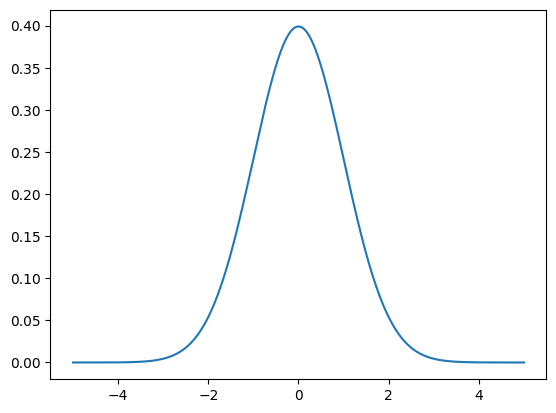

In [28]:
plt.figure()
plt.plot(input_x, pdf_x)
plt.show()

## Extract population distribution parameters

In [10]:
# Set n and p
n = 10
p = 0.5

# True mean and true variance
true_mean = n*p
true_var = n*p*(1-p)

In [11]:
# number of samples
num_samples = 1000

data = sample_binomial(x=num_samples, n=n, p=p)

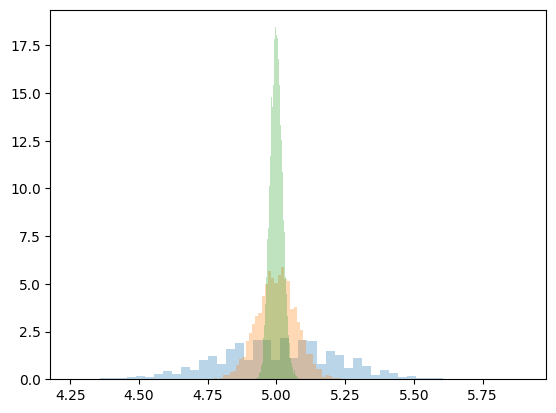

In [29]:
num_realizations = 10000
num_samples_list = [50, 500, 5000]
sample_mean_arr = np.zeros(num_realizations)
for num_samples in num_samples_list:
  for i in range(num_realizations):
    # Draw samples from the binomial
    data = sample_binomial(x=num_samples, n=n, p=p)
    # Obtain the sample mean
    mean_data = np.mean(data)
    # Store in an array
    sample_mean_arr[i] = mean_data
  # Plot
  plt.hist(sample_mean_arr, bins=50, alpha=0.3, density=True)
plt.show()

In [30]:
# Show CTL holds
num_samples = 10000
num_realizations = 100000
sample_mean_arr = np.zeros(num_realizations)
for i in range(num_realizations):
  # Draw samples from the binomial
  data = sample_binomial(x=num_samples, n=n, p=p)
  # Obtain the sample mean
  mean_data = np.mean(data)
  # Store in an array
  sample_mean_arr[i] = mean_data
# Transform the sample mean (subtract the true mean and divide by the true scaled variance)
transformed_means = (sample_mean_arr-true_mean)/(np.sqrt(true_var)/np.sqrt(num_samples))

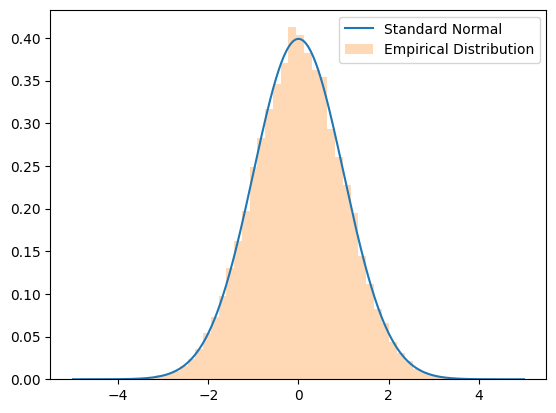

In [31]:
plt.figure()
plt.plot(input_x, pdf_x, label='Standard Normal')
plt.hist(transformed_means, bins=50, density=True, alpha=0.3, label='Empirical Distribution')
plt.legend()
plt.show()